# Cell Cycle Transcription Factors

**Goal:**
Identify groups of cell cycle transcription factors that cycle, with and without gene expression.

**Procedure**
1. Iterate through cell cycle transcription factors
2. Cluster to identify any cycling patterns
3. Correlate with gene expression
4. Quantify/characterize relationship

**Expected outcome**
So far we have seen a small set of genes with chromatin that cycle with gene expression. This same outcome will likely be present with the TFs themselves. Many may follow the same pattern of high occupancy in G1 and low occupancy in S, this follows the occupancy values from replication effects (current hypothesis). For a small set of TFs, we can characterize more or less correlation with gene expression and show some examples.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
from src.tf_sites import TFBindingSites

tf_binding_sites = TFBindingSites()

There are 118 MacIsaac TFs
There are 49 cell cycle transcription factors (CCTFs) profiled by Kelliher, 2018
There are 340 transcription factors profiled using ChIP-exo by Rossi, 2021
There are 17 CCTFS in the Rossi dataset.
There are 22 CCTFS in the MacIsaac dataset.


In [47]:
# We'll start with the 17 rossi sites that have chip-peaks
tf_binding_sites.kelliher_rossi_intersection

# How many sites are there for each of these TFs?
# How many genes are associated with each?

# How many genes are cycling for each?
# How many TFs per gene are cycling for each?

# Organize these questions into a systematic procedure.

array(['NRM1', 'PHD1', 'TAF12', 'ACE2', 'MCM1', 'SWI5', 'SWI4', 'FHL1',
       'UME6', 'SWI6', 'WHI5', 'MET32', 'MBP1', 'FKH2', 'NDD1', 'FKH1',
       'INO4'], dtype='<U5')

In [186]:
rossi_sites = tf_binding_sites.all_rossi_tf_dfs

tf_sites = rossi_sites[rossi_sites.tf == 'Mcm1']

# Will need to look at occupancy values at these site positions...
# Identify nearby genes to correlate to


# Compute the occupancy of small fragments at these sites
# May need to filter out nearby sites


tf_sites = tf_sites.sort_values(['chr', 'start']).reset_index(drop=True)

# First check if a site is near its neigbor
def filter_neighbors(tf_sites, window=200):
    """To avoid overcounting, filter out tf sites that are near neighbors.
    Currently we will default to keeping the first of the two instances.
    
    todo: May need to come up with a better plan for which of the two sites to keep.
    """

    # Recursively run the process until no sites are left to drop 
    original_sites = tf_sites.copy()
    total_dropped = []
    while True:
        drop_sites = []

        for i in range(0, len(tf_sites)-1):

            first = tf_sites.iloc[i]
            second = tf_sites.iloc[i+1]

            if (first.chr == second.chr) and (second.start-first.start < window):
                drop_sites.append(second.name)
        
        tf_sites = tf_sites.drop(drop_sites)
        total_dropped = total_dropped + drop_sites

        if len(drop_sites) == 0: break
    return tf_sites.reset_index(drop=True), original_sites.loc[total_dropped]

window = 200
filtered_tf_sites, dropped_sites = filter_neighbors(tf_sites, window)

print(f"Filtered out {len(dropped_sites)} sites which were within {window} of a nearby site")

Filtered out 28 sites which were within 200 of a nearby site


In [187]:
# Load the chromatin for the tf sites
filtered_tf_sites

,chr,start,stop,identifier,value,.,tf
0,1,2539,2540,chr1_2539_2540,222,.,Mcm1
1,1,68417,68418,chr1_68417_68418,1000,.,Mcm1
2,1,68730,68731,chr1_68730_68731,341,.,Mcm1
3,1,71254,71255,chr1_71254_71255,1000,.,Mcm1
4,1,72103,72104,chr1_72103_72104,170,.,Mcm1
...,...,...,...,...,...,...,...
379,16,770908,770909,chr16_770908_770909,1000,.,Mcm1
380,16,829259,829260,chr16_829259_829260,1000,.,Mcm1
381,16,840354,840355,chr16_840354_840355,41,.,Mcm1
382,16,840713,840714,chr16_840713_840714,309,.,Mcm1


In [48]:
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis

outdir = "output/deconvolved_genome_g0066_offset1_10k_10x10_2024_10_11/"
analysis = GenomeDeconvolutionAnalysis(outdir)


In [55]:
site = filtered_tf_sites.iloc[0]
padding = 400
analysis.load_stacked_mnase_data_for_rossi_site(site, padding=padding)


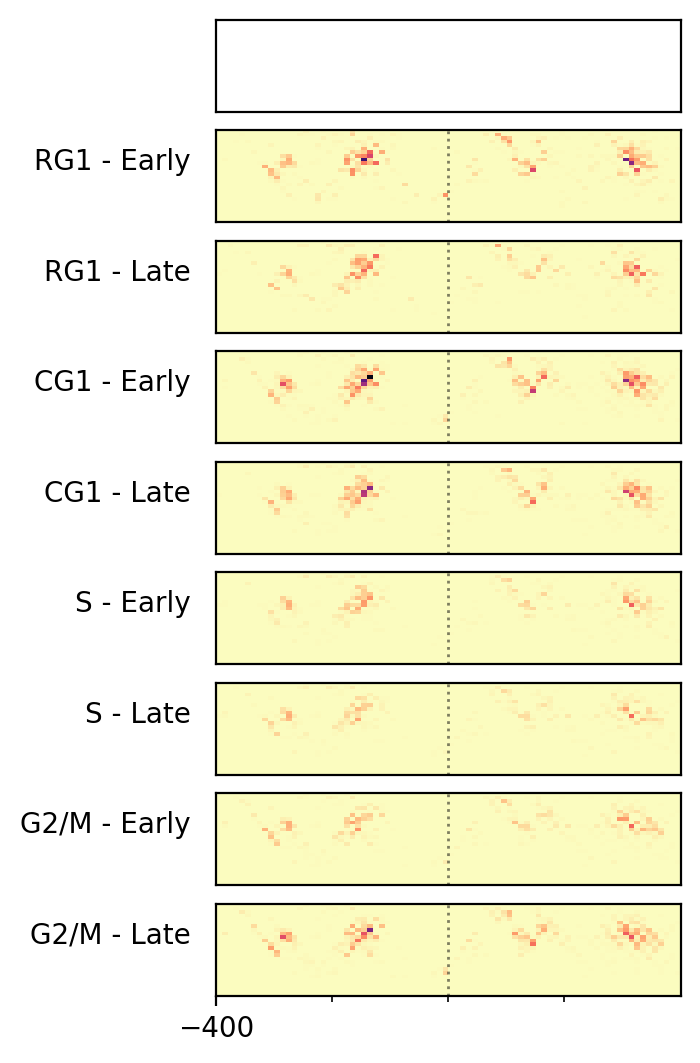

In [59]:
fig = analysis.plot_deconvolved_result(analysis.tf_mnase, mnase_span=(-padding, padding),
                                      figsize=(3, 6), vmax=30)

In [194]:
padding = 400
analysis.load_stacked_mnase_data_for_rossi_sites(filtered_tf_sites, padding=padding)

In [ ]:
fig = analysis.plot_deconvolved_result(analysis.all_tfs_mnase, 
    mnase_span=(-padding, padding), figsize=(3, 6), vmax=10)

# Most of the TFs follow the same pattern of decreasing during S phase, but in the
# example, some of the TFs increased in S phase, cluster the occupancy values to
# identify these loci


In [195]:
analysis.all_tf_occupancies.shape

(384, 178)

In [196]:
from src.gene_clustering import circular_distance
from scipy.stats import pearsonr

def compute_distance_from_gene_expression(time_series_data):

    # Compute the pairwise distance matrix using circular correlation
    n_samples = len(time_series_data)
    distance_matrix = np.zeros((n_samples, n_samples))

    for i in range(n_samples):
        for j in range(i + 1, n_samples):
            pearsonr_val, _ = pearsonr(time_series_data[i], time_series_data[j])
            distance = 1 - pearsonr_val
            distance_matrix[i, j] = distance
            distance_matrix[j, i] = distance

    return distance_matrix


In [ ]:
from src.config import load_configs_by_config_type

config, _ = load_configs_by_config_type('shared')
t_indices = config.get_Hpositions_for_branch('t')

# Distance matrix
tf_occ_t = analysis.all_tf_occupancies[t_indices]

In [214]:
tf_dist = compute_distance_from_gene_expression(tf_occ_t.values)

In [215]:
original_tf_dist = tf_dist.copy()

In [216]:
tf_occ_t.shape, tf_dist.shape

(384, 128)

In [217]:
nonna_indices = np.arange(len(tf_dist))[~np.isnan(tf_dist[0])]
nonna_dist = tf_dist[nonna_indices, :][:, nonna_indices]

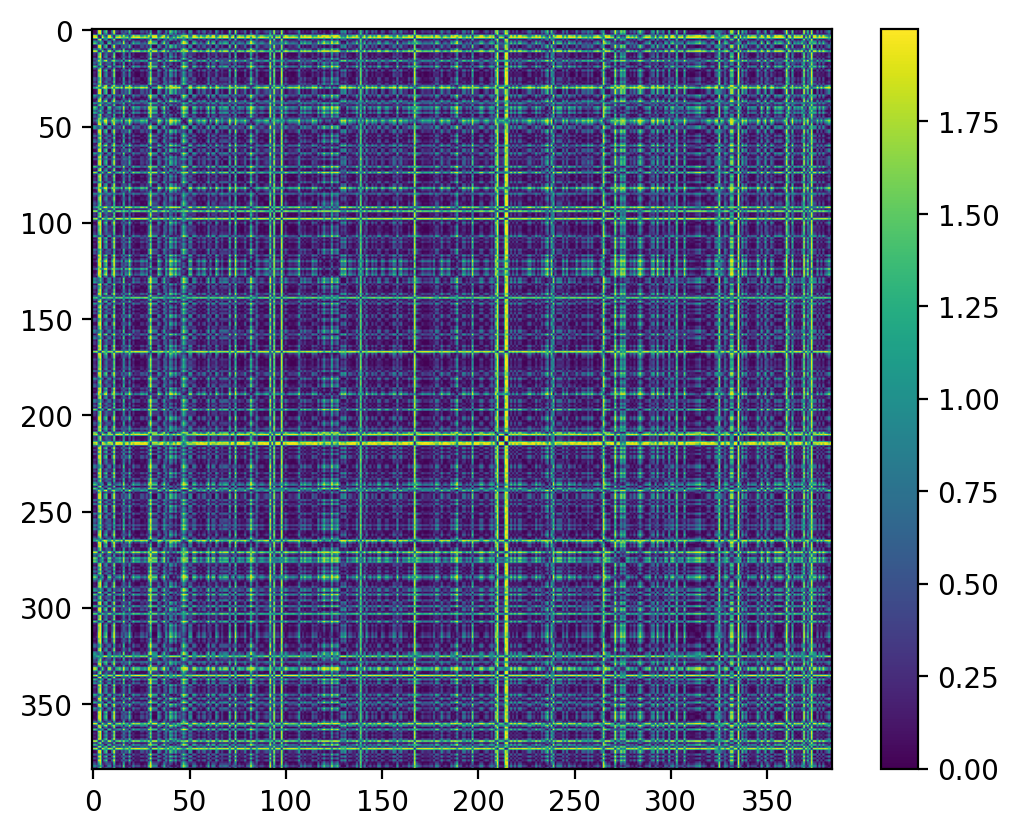

In [218]:
plt.imshow(nonna_dist)
plt.colorbar()

In [222]:
nonna_tf_occ_t = tf_occ_t.loc[nonna_indices]

In [281]:
from sklearn_extra.cluster import KMedoids

n_clusters = 9
kmedoids = KMedoids(n_clusters=n_clusters, metric='precomputed', 
                    method='alternate', init='k-medoids++', random_state=123)
kmedoids.fit(nonna_dist)

KMedoids(init='k-medoids++', metric='precomputed', n_clusters=9,
         random_state=123)

In [282]:
nonnatf_cluster_assignments = nonna_tf_occ_t[[]].copy()
nonnatf_cluster_assignments['cluster'] = kmedoids.labels_
nonnatf_cluster_assignments = nonnatf_cluster_assignments.join(filtered_tf_sites, how='left')


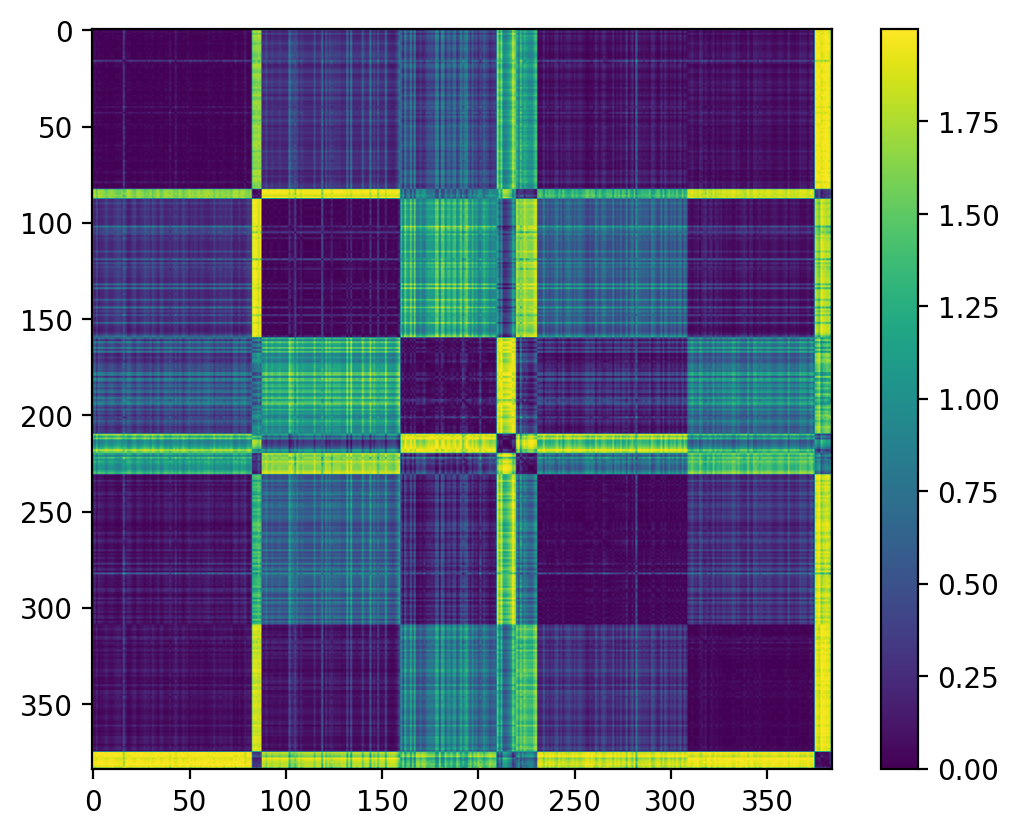

In [283]:
asorted_nonnatf_indices = nonnatf_cluster_assignments.sort_values('cluster').index
sorted_nonnatf_indices = nonnatf_cluster_assignments.sort_values('cluster').index

plt.imshow(nonna_dist[sorted_nonnatf_indices, :][:, sorted_nonnatf_indices])
plt.colorbar()


In [284]:
normalized_cc = (nonna_tf_occ_t - nonna_tf_occ_t.mean(axis=1).values.reshape((-1, 1))) / \
    nonna_tf_occ_t.std(axis=1).values.reshape((-1, 1))

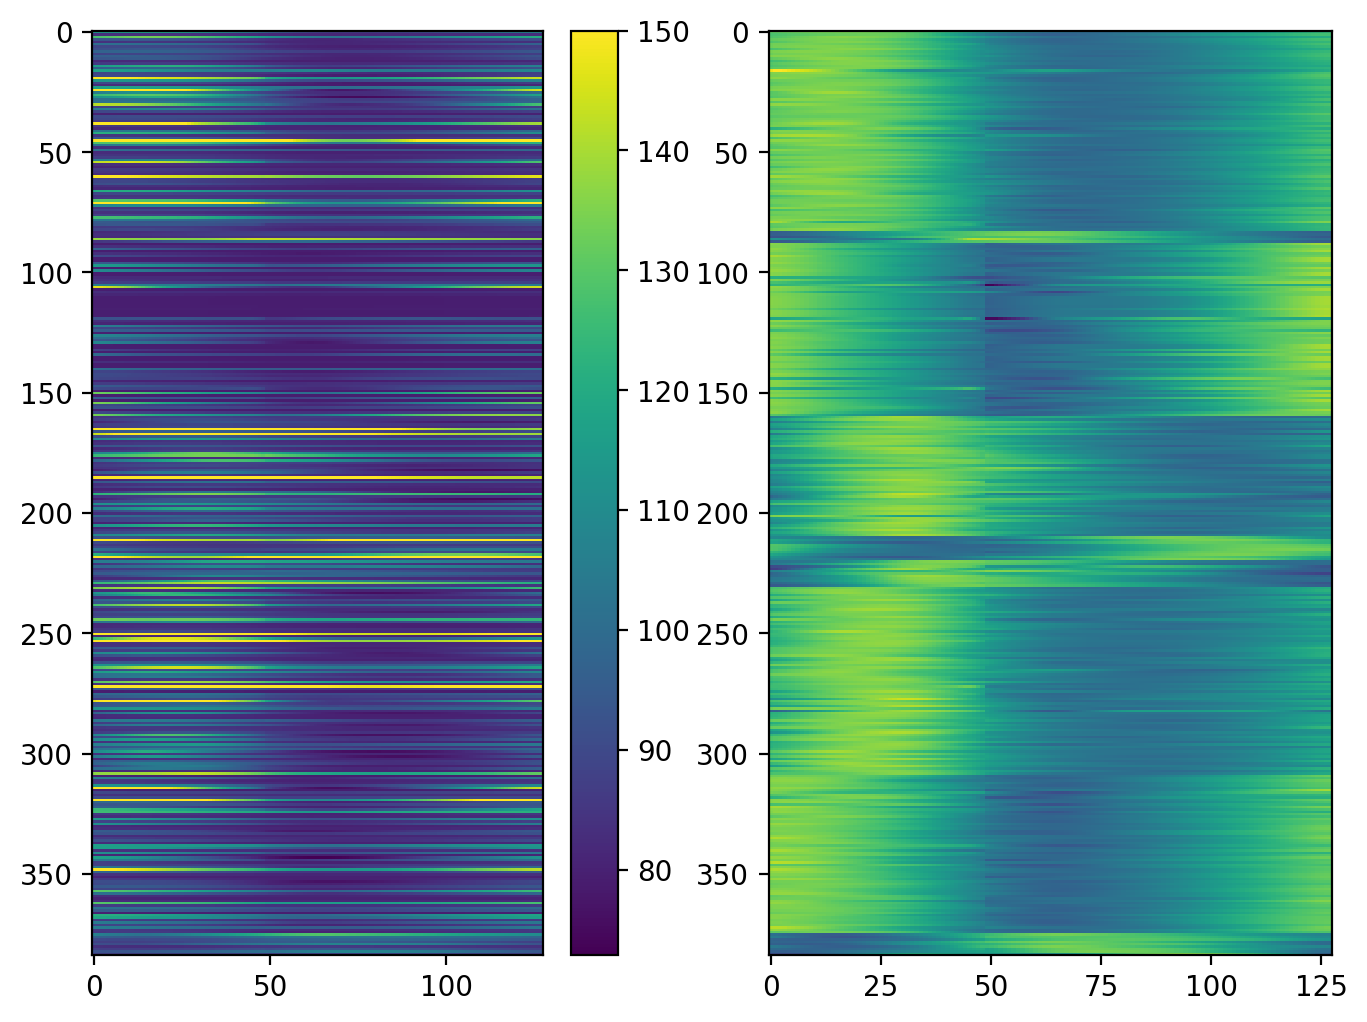

In [285]:
plt.figure(figsize=(8,6))

plt.subplot(1, 2, 1)
plt.imshow(nonna_tf_occ_t.loc[sorted_nonnatf_indices], 
    aspect='auto', interpolation='none', vmax=150)
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(normalized_cc.loc[sorted_nonnatf_indices], 
    aspect='auto', interpolation='none')

In [286]:
nonnatf_cluster_assignments.sort_values('cluster')

,cluster,chr,start,stop,identifier,value,.,tf
383,0,16,927923,927924,chr16_927923_927924,635,.,Mcm1
187,0,10,126576,126577,chr10_126576_126577,795,.,Mcm1
89,0,5,85890,85891,chr5_85890_85891,67,.,Mcm1
87,0,5,77769,77770,chr5_77769_77770,1000,.,Mcm1
190,0,10,181999,182000,chr10_181999_182000,196,.,Mcm1
...,...,...,...,...,...,...,...,...
373,8,16,700790,700791,chr16_700790_700791,484,.,Mcm1
335,8,15,449065,449066,chr15_449065_449066,1000,.,Mcm1
167,8,9,127891,127892,chr9_127891_127892,1000,.,Mcm1
214,8,11,463631,463632,chr11_463631_463632,553,.,Mcm1


Cluster 0
Cluster 1
Cluster 2
Cluster 3
Cluster 4
Cluster 5
Cluster 6
Cluster 7
Cluster 8


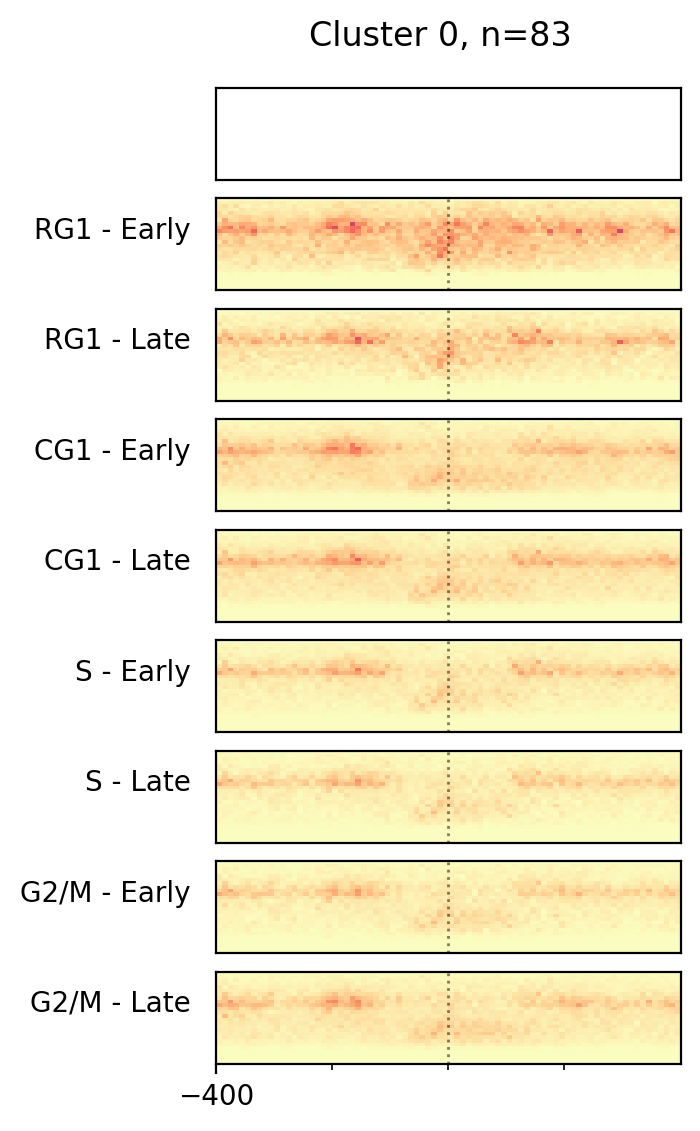

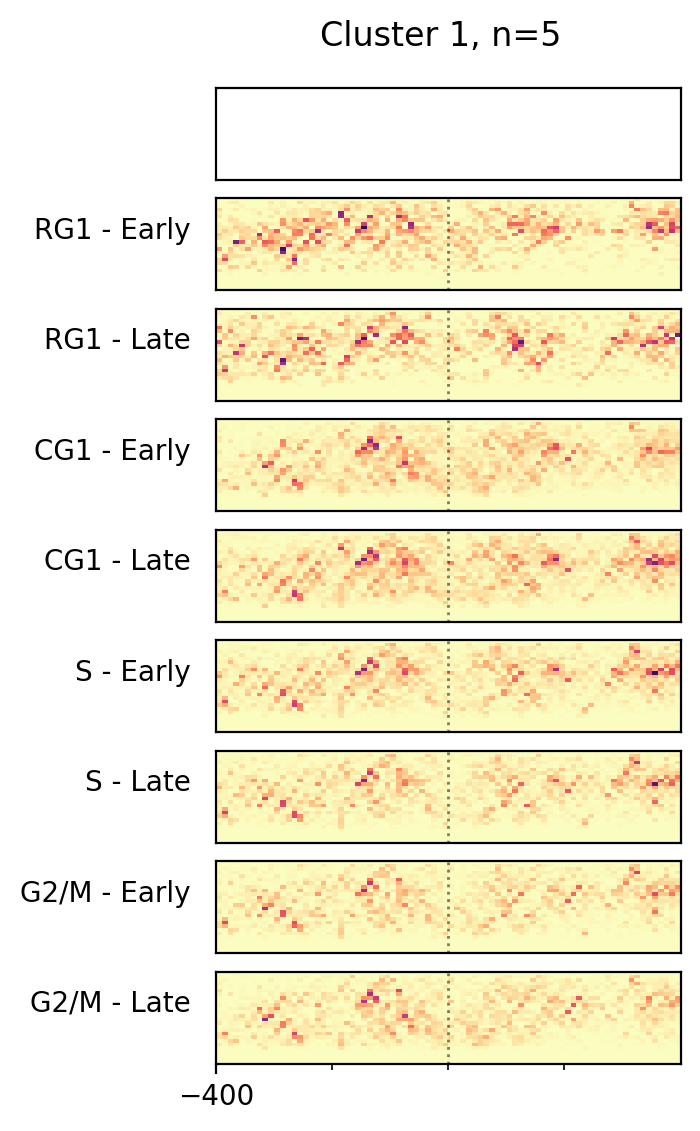

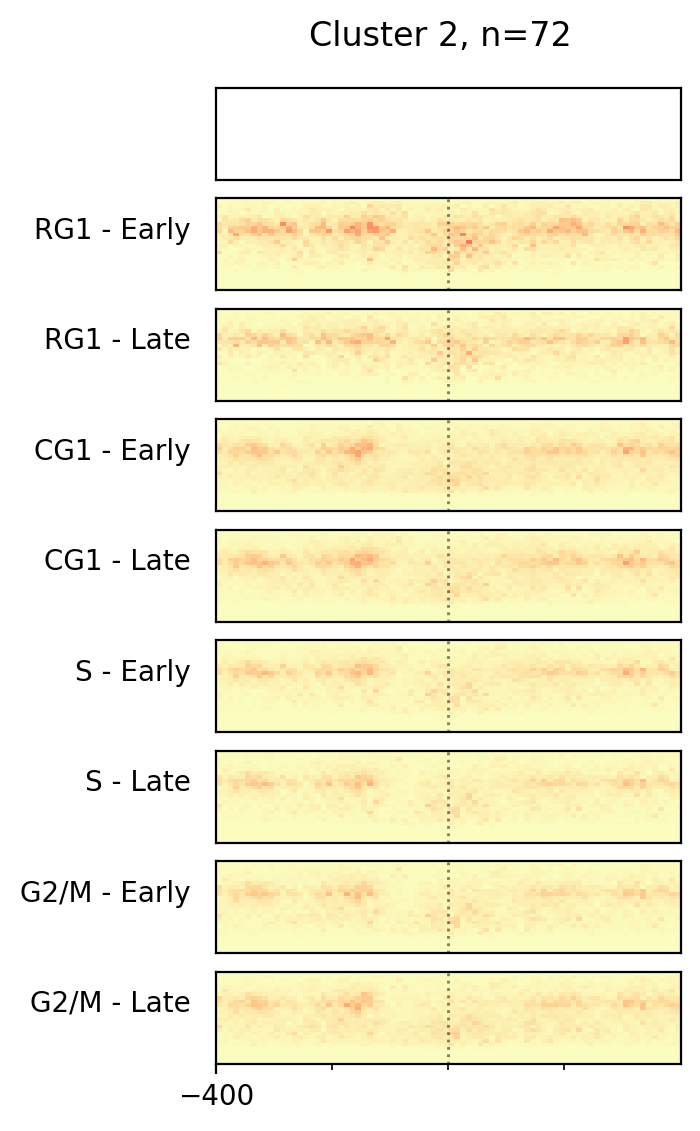

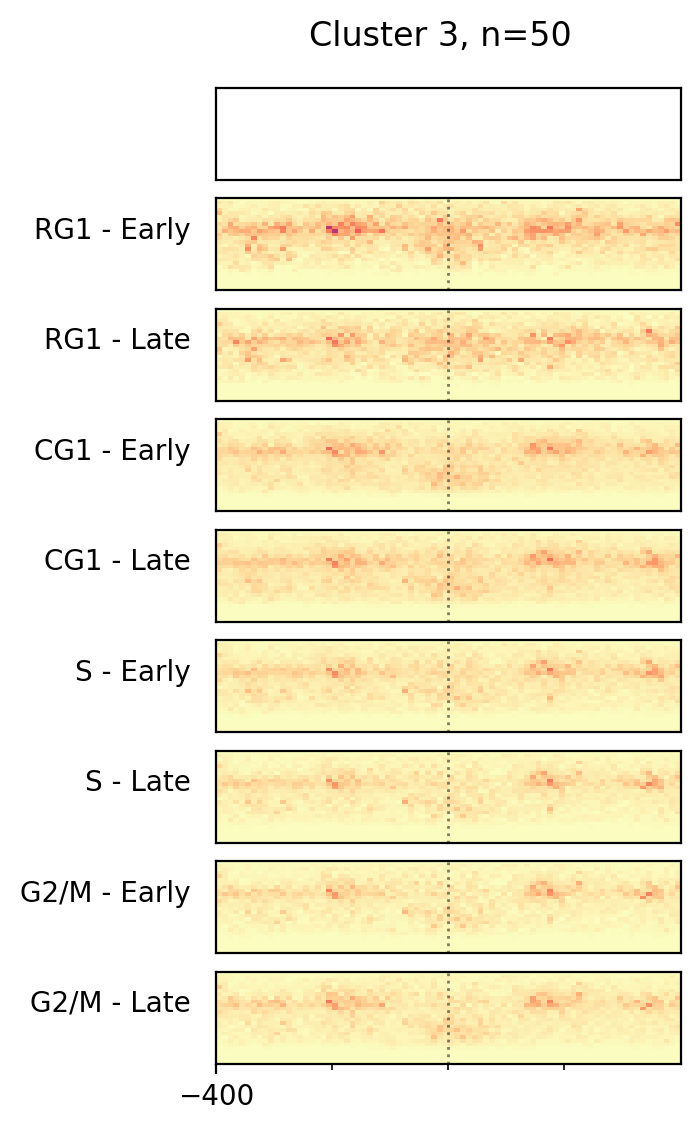

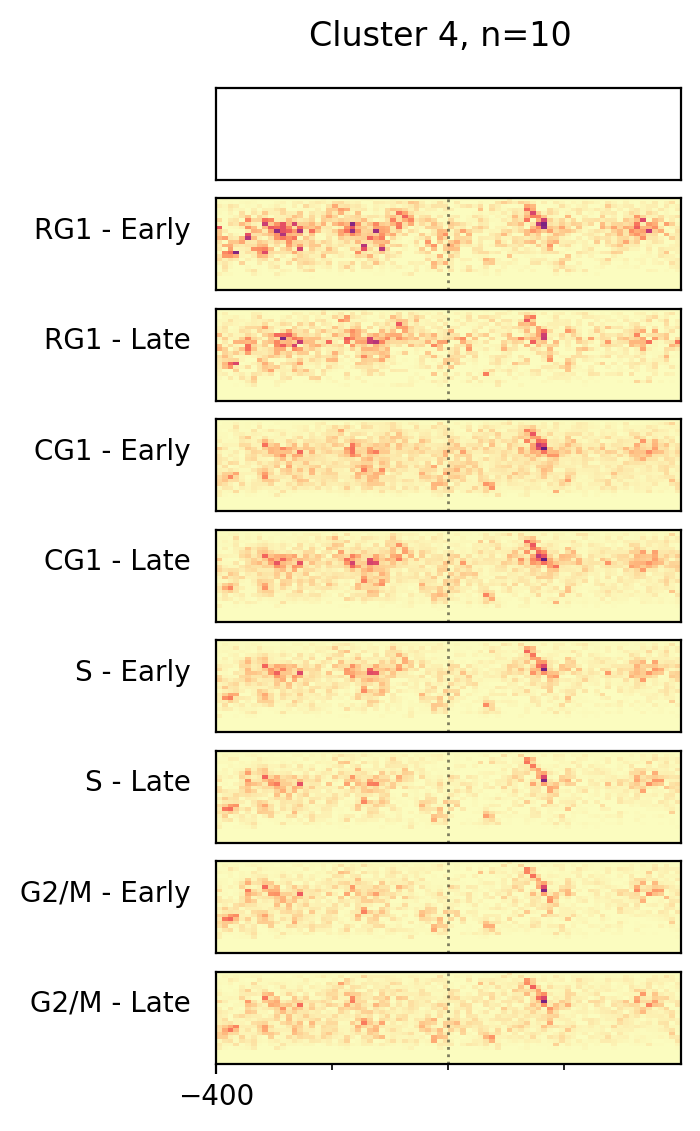

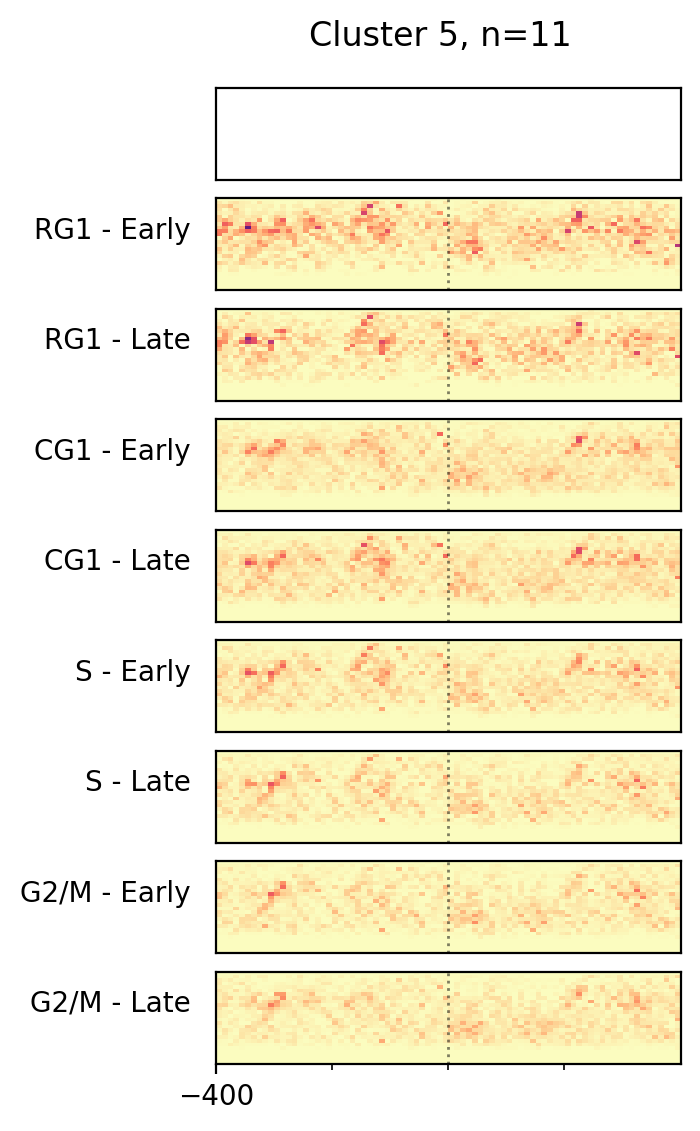

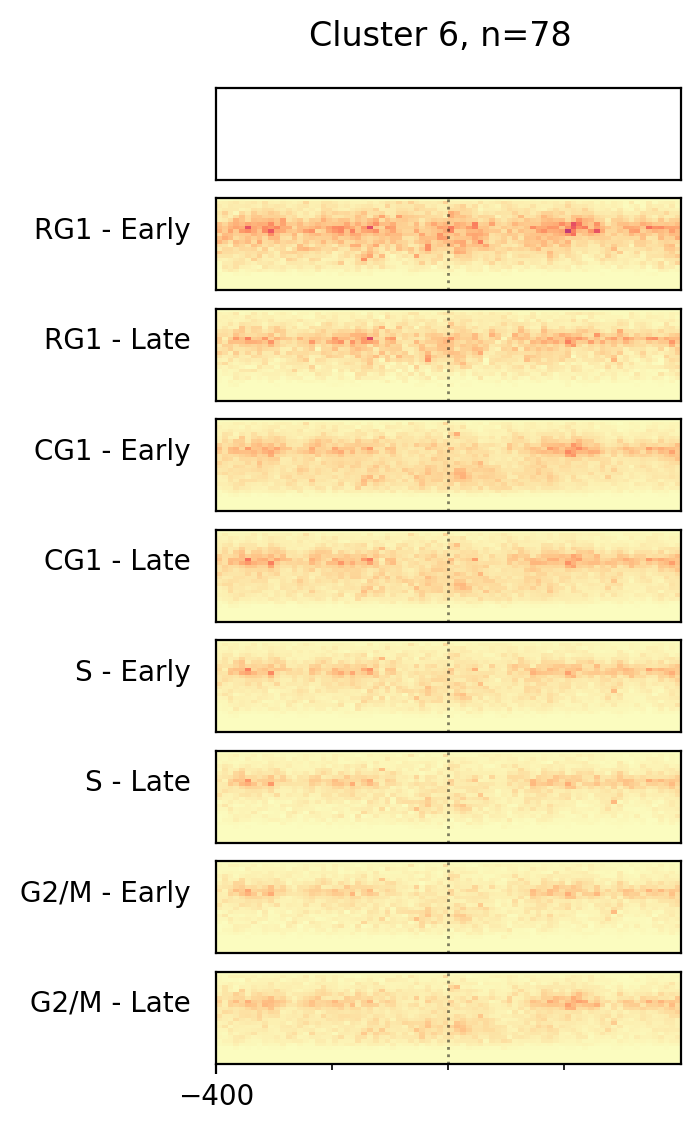

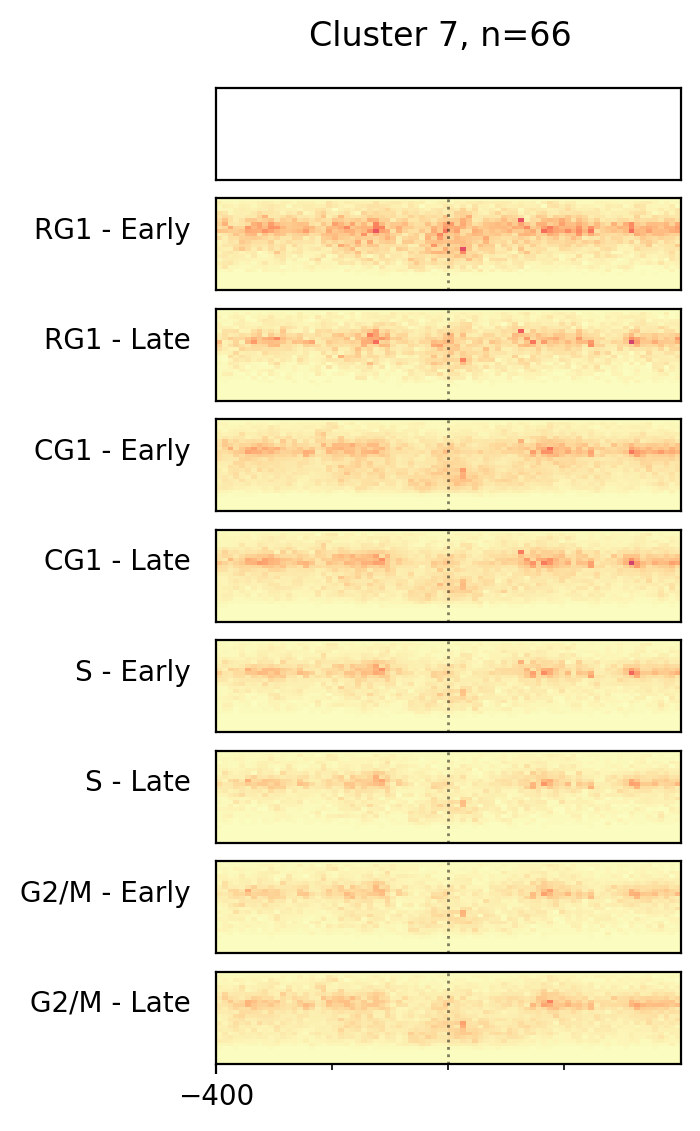

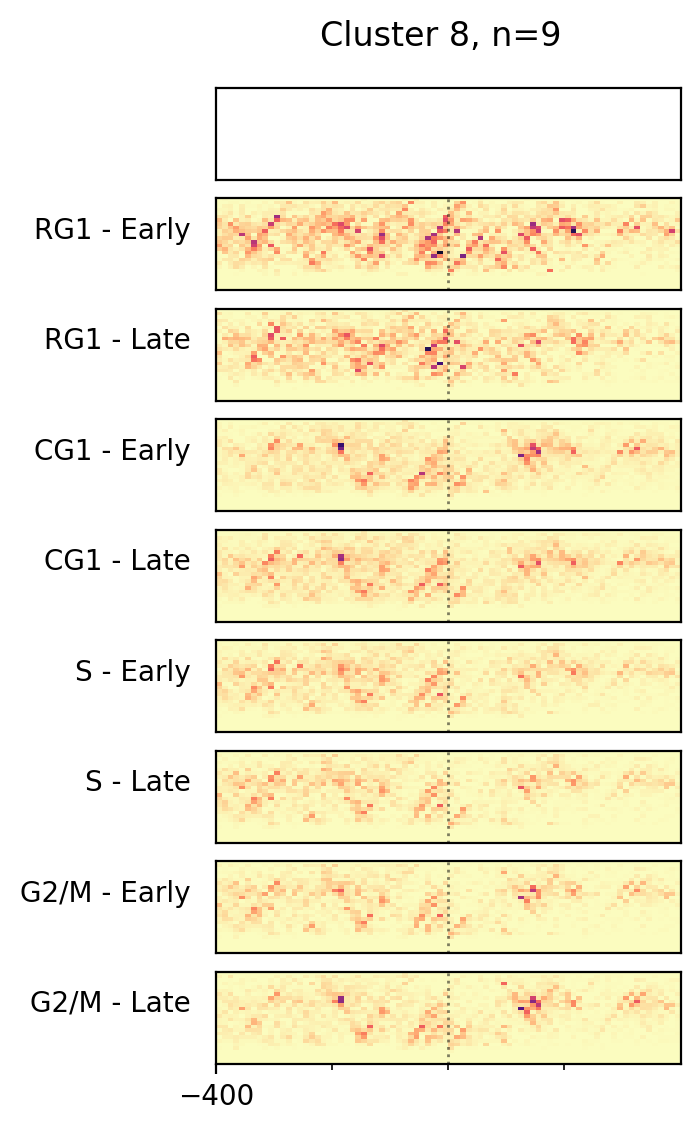

In [288]:
padding = 400

for cluster in range(9):
    print("Cluster", cluster)
    cluster_sites = nonnatf_cluster_assignments[nonnatf_cluster_assignments.cluster == cluster]
    analysis.load_stacked_mnase_data_for_rossi_sites(cluster_sites, padding=padding)
    fig = analysis.plot_deconvolved_result(analysis.all_tfs_mnase, 
    mnase_span=(-padding, padding), figsize=(3, 6), vmax=10)
    plt.suptitle(f"Cluster {cluster}, n={len(cluster_sites)}")
